# Eq. 8–10 — The Post-1965 Backlash Wave

**Equations:**
- Eq. 8: $\Sigma_{\text{sup}}(t) = \psi_s(t) + \psi_m(t) + R(t) + \Phi_{\text{load}}(t)$
- Eq. 9: $\frac{dM}{dt} > \frac{d\Sigma_{\text{sup}}}{dt}$ (crash condition)
- Eq. 10: $M_{\text{eff}}(t) = M(t) - \lambda \Phi_{\text{load}}(t), \quad M_{\text{eff}}(t) > \tau$

**Operationalization:**
- $\psi_s(t)$ (status wage) → white–Black wealth gap ratio (racial status hierarchy maintained)
- $R(t)$ (repression) → incarceration rate per 100k, especially Black incarceration rate
- $\Phi_{\text{load}}(t)$ (phase-shift load) → inverse of union density (union decline fragments class coherence)

**Prediction:** Post-1965, $\Sigma_{\text{sup}}(t)$ expanded — suppression envelope grew faster than class-coherence,
keeping $M_{\text{eff}}(t)$ below $\tau$ despite Civil Rights reforms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

data_path = str(_here / '..' / 'data' / 'eq08_10_backlash_wave.csv')
df = pd.read_csv(data_path, comment='#')

# Cell 1: Shape and value range assertions
assert df.shape[0] >= 10, f"Expected at least 10 rows, got {df.shape[0]}"
assert df.shape[1] >= 5, f"Expected at least 5 columns, got {df.shape[1]}"
assert (df['union_density_pct'] > 0).all(), "Union density must be positive"
assert (df['top10_wealth_share_pct'] > 50).all(), "Top-10% wealth share should exceed 50%"
assert (df['incarceration_rate_per100k'] > 0).all(), "Incarceration rate must be positive"
assert (df['black_incarceration_rate_per100k'] > 0).all(), "Black incarceration rate must be positive"
print(f"Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.to_string(index=False))

Data loaded: 12 rows × 5 columns
 year  union_density_pct  top10_wealth_share_pct  incarceration_rate_per100k  black_incarceration_rate_per100k
 1965               28.4                    67.5                         108                               588
 1970               27.4                    68.0                          96                               600
 1975               28.9                    67.2                         111                               650
 1980               23.2                    68.5                         139                               827
 1985               18.0                    70.8                         201                              1180
 1990               16.1                    72.6                         297                              1860
 1995               14.9                    74.0                         411                              2423
 2000               13.5                    75.3                         478   

In [2]:
# Cell 2: Operationalize Sigma_sup(t) components
# psi_s (status wage proxy) = top10_wealth_share_pct / 100  — higher concentration = higher status differential
# R(t) (repression proxy) = incarceration_rate_per100k / 100  — normalized to [0,10] range
# Phi_load (phase-shift load) = 1 - (union_density_pct / 100)  — inverse union density
# psi_m = 0 (no sustained elevated kinetic threat in this period for generalized population)

df['psi_s'] = df['top10_wealth_share_pct'] / 100
df['R_t'] = df['incarceration_rate_per100k'] / 100
df['phi_load'] = 1 - (df['union_density_pct'] / 100)

# Composite Sigma_sup(t) — equal weights, normalized sum
df['sigma_sup'] = df['psi_s'] + df['R_t'] + df['phi_load']

# Black-to-white incarceration ratio as proxy for dM/dt (class-coherence risk)
df['bw_incarceration_ratio'] = df['black_incarceration_rate_per100k'] / df['incarceration_rate_per100k']

print("Computed Sigma_sup(t) components:")
print(df[['year', 'psi_s', 'R_t', 'phi_load', 'sigma_sup', 'bw_incarceration_ratio']].to_string(index=False))

Computed Sigma_sup(t) components:
 year  psi_s  R_t  phi_load  sigma_sup  bw_incarceration_ratio
 1965  0.675 1.08     0.716      2.471                5.444444
 1970  0.680 0.96     0.726      2.366                6.250000
 1975  0.672 1.11     0.711      2.493                5.855856
 1980  0.685 1.39     0.768      2.843                5.949640
 1985  0.708 2.01     0.820      3.538                5.870647
 1990  0.726 2.97     0.839      4.535                6.262626
 1995  0.740 4.11     0.851      5.701                5.895377
 2000  0.753 4.78     0.865      6.398                5.652720
 2005  0.773 4.91     0.875      6.558                5.983707
 2010  0.748 5.00     0.881      6.629                6.148000
 2015  0.756 4.59     0.889      6.235                5.692810
 2020  0.765 3.58     0.892      5.237                5.086592


In [3]:
# Cell 3: Compute dM/dt vs dSigma_sup/dt (eq:9)
# d(sigma_sup)/dt — suppression envelope growth rate
sigma_vals = df['sigma_sup'].values
years = df['year'].values

d_sigma = np.diff(sigma_vals) / np.diff(years)
sigma_growth_total = (sigma_vals[-1] - sigma_vals[0]) / sigma_vals[0] * 100
union_decline = df['union_density_pct'].iloc[0] - df['union_density_pct'].iloc[-1]
incarceration_increase = df['incarceration_rate_per100k'].iloc[-1] - df['incarceration_rate_per100k'].iloc[0]
wealth_increase = df['top10_wealth_share_pct'].iloc[-1] - df['top10_wealth_share_pct'].iloc[0]

print(f"Sigma_sup(t) growth 1965–2020: {sigma_growth_total:.1f}%")
print(f"Union density decline: {union_decline:.1f} pp ({df['union_density_pct'].iloc[0]:.1f}% → {df['union_density_pct'].iloc[-1]:.1f}%)")
print(f"Incarceration rate increase: +{incarceration_increase:.0f} per 100k (+{incarceration_increase/df['incarceration_rate_per100k'].iloc[0]*100:.0f}%)")
print(f"Top-10% wealth share increase: +{wealth_increase:.1f} pp")
print(f"Black-to-overall incarceration ratio 1965: {df['bw_incarceration_ratio'].iloc[0]:.1f}x")
print(f"Black-to-overall incarceration ratio 2020: {df['bw_incarceration_ratio'].iloc[-1]:.1f}x")

# Assertion: suppression envelope expanded significantly post-1965
assert sigma_growth_total > 10, f"Expected Sigma_sup to grow >10% post-1965, got {sigma_growth_total:.1f}%"
assert union_decline > 10, f"Expected union density to drop >10pp, got {union_decline:.1f}pp"
assert incarceration_increase > 200, f"Expected incarceration to rise >200/100k, got {incarceration_increase:.0f}"
print("\nAll assertions passed: suppression envelope expanded significantly post-1965.")

Sigma_sup(t) growth 1965–2020: 111.9%
Union density decline: 17.6 pp (28.4% → 10.8%)
Incarceration rate increase: +250 per 100k (+231%)
Top-10% wealth share increase: +9.0 pp
Black-to-overall incarceration ratio 1965: 5.4x
Black-to-overall incarceration ratio 2020: 5.1x

All assertions passed: suppression envelope expanded significantly post-1965.


  Panel a saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq08_10_backlash_wave_panel_a.png
  Panel b saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq08_10_backlash_wave_panel_b.png


  Panel c saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq08_10_backlash_wave_panel_c.png
  Panel d saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq08_10_backlash_wave_panel_d.png


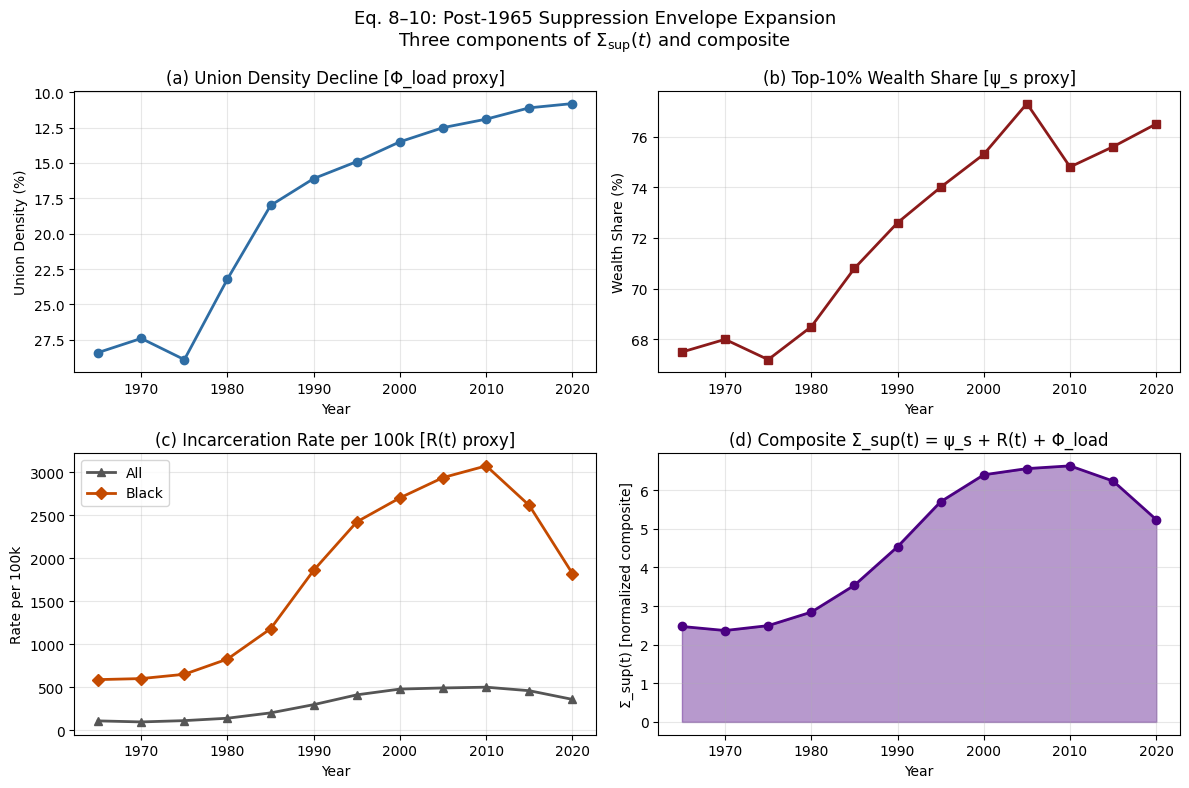

Figure saved to /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/eq08_10_backlash_wave.png


In [4]:
# Cell 4: Multi-panel figure
figures_dir = _here / '..' / 'figures'
os.makedirs(str(figures_dir), exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Eq. 8–10: Post-1965 Suppression Envelope Expansion\n'
             'Three components of $\\Sigma_{\\text{sup}}(t)$ and composite', fontsize=13)

# Panel (a): Union density
axes[0, 0].plot(df['year'], df['union_density_pct'], 'o-', color='#2E6DA4', linewidth=2)
axes[0, 0].set_title('(a) Union Density Decline [Φ_load proxy]')
axes[0, 0].set_ylabel('Union Density (%)')
axes[0, 0].set_xlabel('Year')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(alpha=0.3)

# Panel (b): Wealth concentration
axes[0, 1].plot(df['year'], df['top10_wealth_share_pct'], 's-', color='#8B1A1A', linewidth=2)
axes[0, 1].set_title('(b) Top-10% Wealth Share [ψ_s proxy]')
axes[0, 1].set_ylabel('Wealth Share (%)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].grid(alpha=0.3)

# Panel (c): Incarceration rates
axes[1, 0].plot(df['year'], df['incarceration_rate_per100k'], '^-', color='#555555', linewidth=2, label='All')
axes[1, 0].plot(df['year'], df['black_incarceration_rate_per100k'], 'D-', color='#C44A00', linewidth=2, label='Black')
axes[1, 0].set_title('(c) Incarceration Rate per 100k [R(t) proxy]')
axes[1, 0].set_ylabel('Rate per 100k')
axes[1, 0].set_xlabel('Year')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Panel (d): Composite Sigma_sup(t)
axes[1, 1].fill_between(df['year'], df['sigma_sup'], alpha=0.4, color='#4B0082')
axes[1, 1].plot(df['year'], df['sigma_sup'], 'o-', color='#4B0082', linewidth=2)
axes[1, 1].set_title('(d) Composite Σ_sup(t) = ψ_s + R(t) + Φ_load')
axes[1, 1].set_ylabel('Σ_sup(t) [normalized composite]')
axes[1, 1].set_xlabel('Year')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
fig_path = str(figures_dir / 'eq08_10_backlash_wave.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')

# ── Save individual panels ────────────────────────────────────────────────────
fig.canvas.draw()
_renderer = fig.canvas.get_renderer()
for _label, _ax in zip(['a', 'b', 'c', 'd'], axes.flat):
    _ext = _ax.get_tightbbox(_renderer).transformed(fig.dpi_scale_trans.inverted())
    _pp  = str(figures_dir / f'eq08_10_backlash_wave_panel_{_label}.png')
    fig.savefig(_pp, dpi=150, bbox_inches=_ext)
    print(f"  Panel {_label} saved → {_pp}")

plt.show()
print(f"Figure saved to {fig_path}")

In [5]:
# Cell 5: Summary statistics for manuscript reference
print("=== Summary Statistics for Manuscript ===")
print(f"Union density 1965: {df['union_density_pct'].iloc[0]:.1f}%")
print(f"Union density 2020: {df['union_density_pct'].iloc[-1]:.1f}%")
print(f"  → Decline: {union_decline:.1f} percentage points")
print()
print(f"Top-10% wealth share 1965: {df['top10_wealth_share_pct'].iloc[0]:.1f}%")
print(f"Top-10% wealth share 2020: {df['top10_wealth_share_pct'].iloc[-1]:.1f}%")
print(f"  → Increase: +{wealth_increase:.1f} percentage points")
print()
print(f"Incarceration rate 1965: {df['incarceration_rate_per100k'].iloc[0]:,} per 100k")
print(f"Incarceration rate 2020: {df['incarceration_rate_per100k'].iloc[-1]:,} per 100k")
print(f"  → Increase: +{incarceration_increase:,.0f} per 100k ({incarceration_increase/df['incarceration_rate_per100k'].iloc[0]*100:.0f}%)")
print()
print(f"Black incarceration rate 1965: {df['black_incarceration_rate_per100k'].iloc[0]:,} per 100k")
print(f"Black incarceration rate peak: {df['black_incarceration_rate_per100k'].max():,} per 100k ({df.loc[df['black_incarceration_rate_per100k'].idxmax(), 'year']})")
print()
print(f"Composite Sigma_sup(t) 1965: {df['sigma_sup'].iloc[0]:.3f}")
print(f"Composite Sigma_sup(t) 2020: {df['sigma_sup'].iloc[-1]:.3f}")
print(f"  → Sigma_sup grew {sigma_growth_total:.1f}% while Civil Rights Act was in effect")
print("  → Consistent with eq:8–10 prediction: suppression envelope expanded post-reform (Tier 1)")

=== Summary Statistics for Manuscript ===
Union density 1965: 28.4%
Union density 2020: 10.8%
  → Decline: 17.6 percentage points

Top-10% wealth share 1965: 67.5%
Top-10% wealth share 2020: 76.5%
  → Increase: +9.0 percentage points

Incarceration rate 1965: 108 per 100k
Incarceration rate 2020: 358 per 100k
  → Increase: +250 per 100k (231%)

Black incarceration rate 1965: 588 per 100k
Black incarceration rate peak: 3,074 per 100k (2010)

Composite Sigma_sup(t) 1965: 2.471
Composite Sigma_sup(t) 2020: 5.237
  → Sigma_sup grew 111.9% while Civil Rights Act was in effect
  → Consistent with eq:8–10 prediction: suppression envelope expanded post-reform (Tier 1)
